# Distribución Posterior

In [70]:
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

data = pd.read_csv("../data/clean/datos_limpios.csv")
data = data.dropna()
data["subtotal"] = (
    data["subtotal"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .pipe(pd.to_numeric, errors="coerce")
)

## Binomial-Lognormal

In [71]:
from cmdstanpy import CmdStanModel
import arviz as az
import pandas as pd
import numpy as np
import os, tempfile

# Define outcome y tamaño
data['y'] = data['subtotal'].astype(int)
data['n'] = data['total'].astype(int)

# Filtra filas válidas
covars = [
    'desempleo','poblacion_urbana','privacion_critica',
    'poblacion_menor_14','hogares_monomarentales',
    'ocupantes_por_hogar','anos_escolaridad'
]
cols_needed = ['distrito','y','n'] + covars
df = data[cols_needed].dropna().copy()

# Asegura bounds binomiales
df = df[(df['n'] >= 1) & (df['y'].between(0, df['n']))].copy()

# Estandariza covariables (recomendado para HMC)
for c in covars:
    m, s = df[c].mean(), df[c].std(ddof=0)
    df[c] = (df[c] - m) / (s if s > 0 else 1.0)

# Codifica distrito a IDs 1..J
df['distrito_id'], distrito_levels = pd.factorize(df['distrito'], sort=True)
df['distrito_id'] += 1
J = df['distrito_id'].max()

# Matriz de diseño
X = df[covars].to_numpy()
N, K = X.shape
y = df['y'].to_numpy().astype(int)
n = df['n'].to_numpy().astype(int)
dist_id = df['distrito_id'].to_numpy().astype(int)

# === 2) Modelo Stan (no conjugado, logit-normal en efectos lineales) ===
stan_code = r"""
data {
  int<lower=1> N;                       // observaciones
  int<lower=1> K;                       // # covariables
  int<lower=1> J;                       // # distritos
  array[N] int<lower=0> y;              // casos
  array[N] int<lower=1> n;              // totales
  matrix[N, K] X;                       // covariables estandarizadas
  array[N] int<lower=1, upper=J> dist_id; // índice de distrito
}
parameters {
  real alpha0;                          // intercepto global
  vector[K] beta;                       // coeficientes
  real<lower=0> sigma_alpha;            // sd de interceptos por distrito
  vector[J] z_alpha;                    // no centrado
}
transformed parameters {
  vector[J] alpha = sigma_alpha * z_alpha; // interceptos por distrito
}
model {
  // Priores débiles (NO conjugadas con binomial-logit)
  alpha0 ~ normal(0, 2);
  beta   ~ normal(0, 1);
  sigma_alpha ~ normal(0, 1);           // half-N por restricción a >0
  z_alpha ~ normal(0, 1);

  // Verosimilitud
  for (i in 1:N) {
    real eta = alpha0 + alpha[dist_id[i]] + X[i] * beta; // X[i] es row-vector
    y[i] ~ binomial_logit(n[i], eta);
  }
}
generated quantities {
  vector[N] theta;
  array[N] int y_rep;
  for (i in 1:N) {
    real eta = alpha0 + alpha[dist_id[i]] + X[i] * beta;
    theta[i] = inv_logit(eta);
    y_rep[i] = binomial_rng(n[i], theta[i]); // posterior predictive
  }
}
"""


# === 3) Compila ===
tmpdir = tempfile.mkdtemp(prefix="stan_prevlogit_")
stan_file = os.path.join(tmpdir, "binomial_logit_hier.stan")
with open(stan_file, "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file=stan_file)

# === 4) MAP (opcional) ===
map_fit = model.optimize(data={
    "N": N, "K": K, "J": J,
    "y": y, "n": n, "X": X, "dist_id": dist_id
}, seed=123)
map_theta = map_fit.stan_variable("theta")
print("[MAP] Prev. media:", map_theta.mean())

# === 5) MCMC (distribución estacionaria/posterior) ===
fit = model.sample(
    data={"N": N, "K": K, "J": J, "y": y, "n": n, "X": X, "dist_id": dist_id},
    chains=4, parallel_chains=4, seed=123,
    iter_warmup=1000, iter_sampling=2000
)
print(fit.summary())

# === 6) Resúmenes útiles ===
theta_draws = fit.stan_variable("theta")   # shape: (draws, N)
theta_mean  = theta_draws.mean(axis=0)
theta_ci    = np.quantile(theta_draws, [0.025, 0.975], axis=0).T

res = df[['distrito','y','n']].copy()
res['prev_estimada'] = theta_mean
res['ci_low'] = theta_ci[:,0]
res['ci_high'] = theta_ci[:,1]
print(res.head())

# ArviZ (opcional)
idata = az.from_cmdstanpy(posterior=fit)
print(az.summary(idata, var_names=['alpha0','beta','sigma_alpha'], kind='stats'))


13:17:05 - cmdstanpy - INFO - compiling stan file C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5_ft_6gm\binomial_logit_hier.stan to exe file C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5_ft_6gm\binomial_logit_hier.exe
13:20:18 - cmdstanpy - INFO - compiled model executable: C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5_ft_6gm\binomial_logit_hier.exe
13:20:19 - cmdstanpy - INFO - Chain [1] start processing
13:20:19 - cmdstanpy - INFO - Chain [1] done processing
13:20:19 - cmdstanpy - INFO - CmdStan start processing


[MAP] Prev. media: 0.22319276324093815


chain 1 |                                                                                                | 00:00 Status
chain 2 |                                                                                                | 00:00 Status

chain 3 |                                                                                                | 00:00 Status


chain 4 |                                                                                                | 00:00 Status
chain 2 |███▉                                                           | 00:50 Iteration:    1 / 3000 [  0%]  (Warmup)


chain 4 |███▉                                                           | 00:51 Iteration:    1 / 3000 [  0%]  (Warmup)

chain 1 |███▉                                                           | 00:57 Iteration:    1 / 3000 [  0%]  (Warmup)
chain 2 |█████▉                                                         | 01:01 Iteration:  100 / 3000 [  3%]  (Warmup)


chain 4 |█████▉                 


13:23:47 - cmdstanpy - INFO - CmdStan done processing.



                      Mean      MCSE     StdDev        MAD             5%  \
lp__        -555816.000000  0.483151  19.985300  19.881700 -555850.000000   
alpha0           -1.247640  0.000233   0.007884   0.007785      -1.260630   
beta[1]          -0.006435  0.000120   0.006760   0.006758      -0.017647   
beta[2]           0.028143  0.000192   0.010063   0.010156       0.011357   
beta[3]          -0.081250  0.000266   0.012849   0.012874      -0.102202   
...                    ...       ...        ...        ...            ...   
y_rep[1403]     206.570000  0.163307  14.403100  14.826000     183.000000   
y_rep[1404]     206.672000  0.155251  14.353100  14.826000     183.000000   
y_rep[1405]      16.318000  0.041914   3.770700   4.447800      10.000000   
y_rep[1406]      16.300500  0.042030   3.812020   4.447800      10.000000   
y_rep[1407]      16.348100  0.041814   3.822210   4.447800      10.000000   

                       50%            95%  ESS_bulk  ESS_tail  ESS_bulk/s 

KeyError: 'Coords should follow mapping format {coord_name:[dim1, dim2]}. Check that coords structure is correct and dimensions are valid. "\'beta_dim\' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({\'chain\': 4, \'draw\': 2000, \'beta_dim_0\': 7, \'z_alpha_dim_0\': 377, \'alpha_dim_0\': 377, \'theta_dim_0\': 1407, \'y_rep_dim_0\': 1407})"'

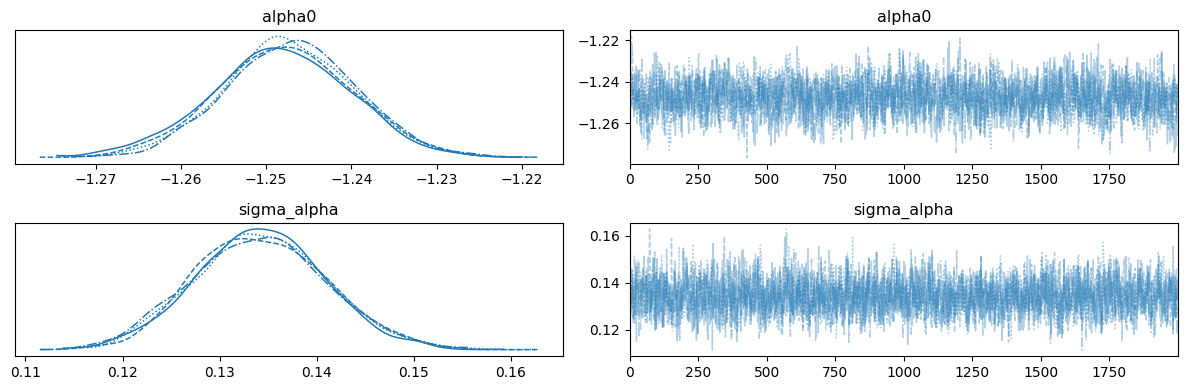

In [57]:
# --- TRAZAS CON ARVIZ ---
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Parámetros globales
az.plot_trace(idata, var_names=["alpha0", "sigma_alpha"])
plt.tight_layout()

# Algunas betas (ajusta índices a tu K)
# Por ejemplo, primeras 3 betas:
az.plot_trace(idata, var_names=["beta"], coords={"beta_dim": [0, 1, 2]})
plt.tight_layout()

# Trazas de theta: elige 6 distritos (por ejemplo, los 6 con mayor n)
top_idx = np.argsort(-n)[:6]  # índices de filas con mayor 'n'
# O manualmente: top_idx = [0, 5, 10, 20, 30, 40]

# Crea un InferenceData solo con esas thetas (para trazas limpias)
# Nota: 'theta' ya está en generated quantities; ArviZ lo toma como posterior
az.plot_trace(
    idata,
    var_names=["theta"],
    coords={"theta_dim_0": top_idx},
)
plt.tight_layout()


In [55]:
print(idata.posterior.dims)
# => {'chain': 4, 'draw': 2000, 'beta_dim_0': 7, 'z_alpha_dim_0': 377, 'alpha_dim_0': 377, 'theta_dim_0': 1407, 'y_rep_dim_0': 1407}


FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 2000, 'beta_dim_0': 7, 'z_alpha_dim_0': 377, 'alpha_dim_0': 377, 'theta_dim_0': 1407, 'y_rep_dim_0': 1407})


array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

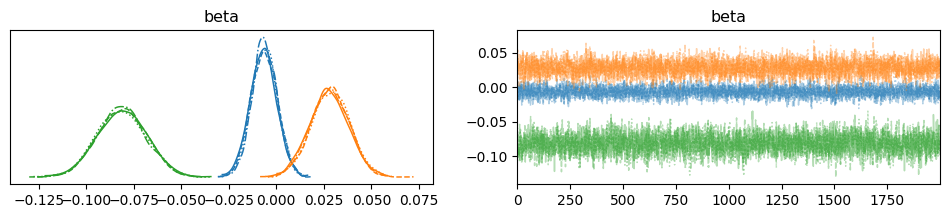

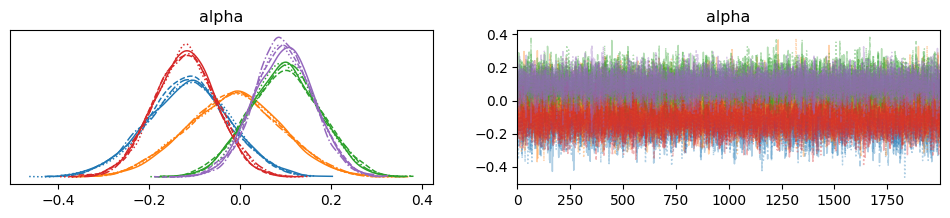

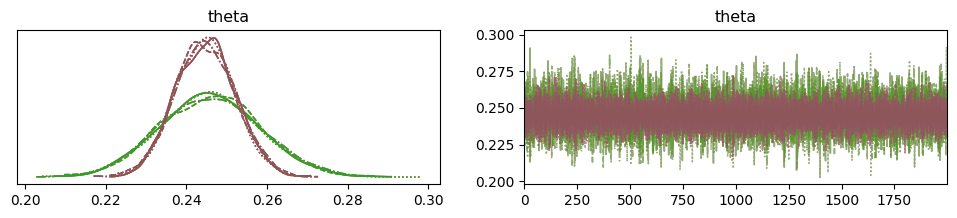

In [58]:
import arviz as az

# Betas 0,1,2
az.plot_trace(idata, var_names=["beta"], coords={"beta_dim_0": [0, 1, 2]})

# alpha (interceptos por distrito) para 5 distritos
az.plot_trace(idata, var_names=["alpha"], coords={"alpha_dim_0": [0, 10, 50, 100, 150]})

# theta para 6 observaciones (p.ej. las primeras)
az.plot_trace(idata, var_names=["theta"], coords={"theta_dim_0": [0, 1, 2, 3, 4, 5]})


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

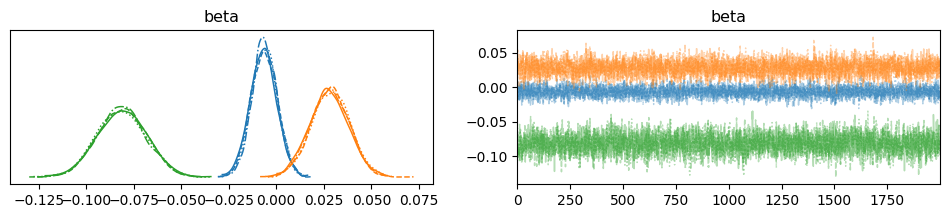

In [60]:
covar_names = covars  # tu lista de columnas X, en el mismo orden que construiste X
idx = [covar_names.index(c) for c in ['desempleo','poblacion_urbana','privacion_critica']]
az.plot_trace(idata, var_names=["beta"], coords={"beta_dim_0": idx})

## Trayectorias

In [64]:
import numpy as np

# 1) EXTRAER DRAWS (ya los tienes)
theta_draws = fit.stan_variable("theta")      # shape: (draws, N)
alpha0_draws = fit.stan_variable("alpha0")    # shape: (draws,)
sigma_draws  = fit.stan_variable("sigma_alpha")

# 2) ELEGIR DOS DISTRITOS POR NOMBRE (o por índice)
distrito_names = list(distrito_levels)        # viene del factorize que hiciste
# Ejemplo: elige por nombre exacto
nombre_i = distrito_names[0]
nombre_j = distrito_names[10]
i = distrito_names.index(nombre_i)
j = distrito_names.index(nombre_j)

# Serie de los dos parámetros a trazar (cambia por alpha0_draws/sigma_draws si prefieres)
a = theta_draws[:, i]   # theta del distrito i
b = theta_draws[:, j]   # theta del distrito j

step = np.arange(1, len(a)+1)  # 1..#draws


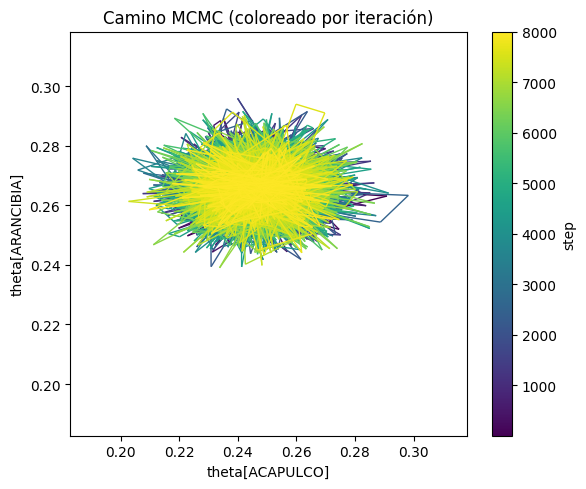

In [63]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

fig, ax = plt.subplots(figsize=(6,5))

# Construir segmentos consecutivos (a_t, b_t) -> (a_{t+1}, b_{t+1})
pts = np.column_stack([a, b])
segments = np.stack([pts[:-1], pts[1:]], axis=1)

lc = LineCollection(
    segments,
    cmap="viridis",  # paleta
    norm=plt.Normalize(step.min(), step.max())
)
lc.set_array(step[1:])      # color por iteración
lc.set_linewidth(1.0)
ax.add_collection(lc)

ax.set_xlim(min(a.min(), b.min())-0.02, max(a.max(), b.max())+0.02)
ax.set_ylim(min(a.min(), b.min())-0.02, max(a.max(), b.max())+0.02)
ax.set_xlabel(f"theta[{nombre_i}]")
ax.set_ylabel(f"theta[{nombre_j}]")
ax.set_title("Camino MCMC (coloreado por iteración)")
cb = plt.colorbar(lc, ax=ax, label="step")
plt.tight_layout()
plt.show()


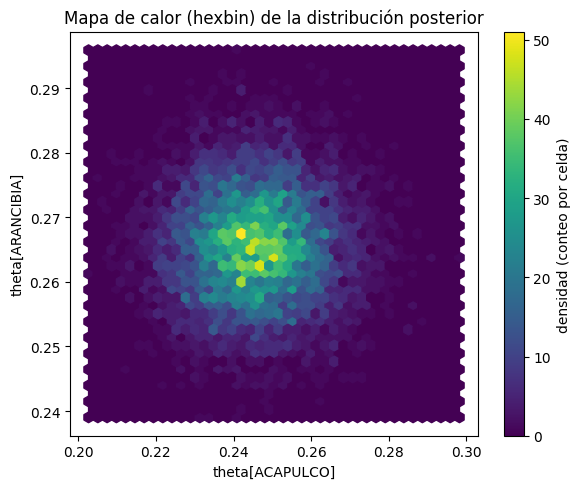

In [65]:
plt.figure(figsize=(6,5))
hb = plt.hexbin(a, b, gridsize=40, cmap="viridis")
plt.colorbar(hb, label="densidad (conteo por celda)")
plt.xlabel(f"theta[{nombre_i}]")
plt.ylabel(f"theta[{nombre_j}]")
plt.title("Mapa de calor (hexbin) de la distribución posterior")
plt.tight_layout()
plt.show()


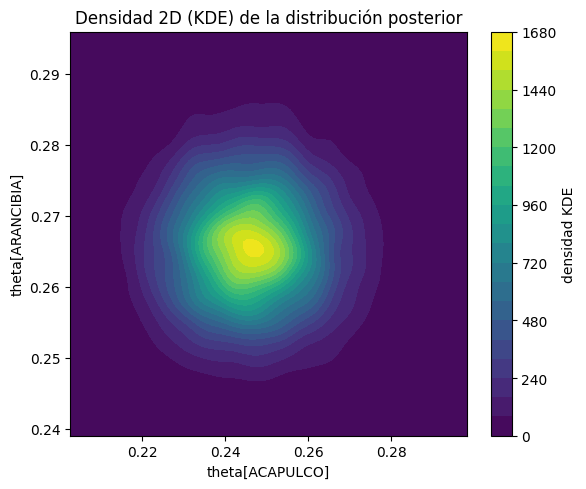

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

xy = np.vstack([a, b])
kde = gaussian_kde(xy)

# malla
xmin, xmax = a.min(), a.max()
ymin, ymax = b.min(), b.max()
xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 120),
    np.linspace(ymin, ymax, 120)
)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, zz, levels=20, cmap="viridis")
plt.colorbar(label="densidad KDE")
plt.xlabel(f"theta[{nombre_i}]")
plt.ylabel(f"theta[{nombre_j}]")
plt.title("Densidad 2D (KDE) de la distribución posterior")
plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

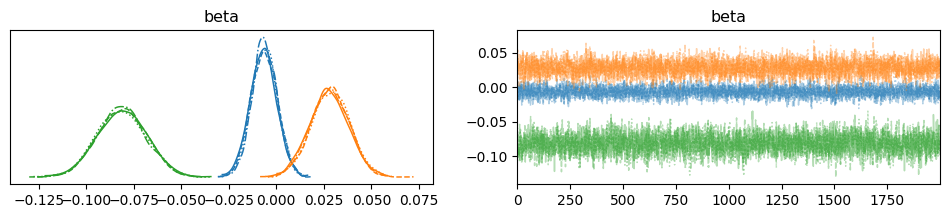

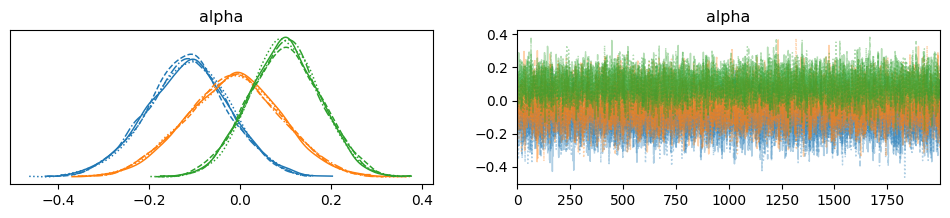

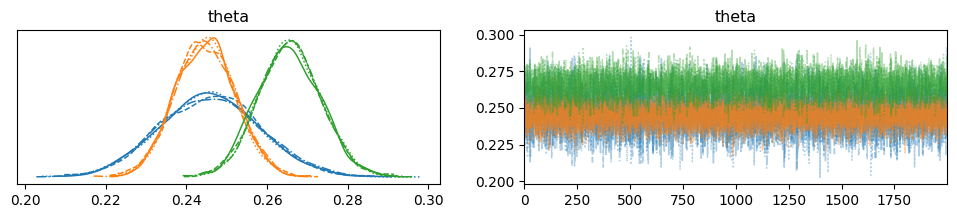

In [68]:
covar_names     = covars                              # tu lista de columnas X
distrito_names  = list(distrito_levels)               # del factorize
obs_index       = df.index.to_numpy()                 # o range(N)

coords = {
    "covar": covar_names,
    "distrito": distrito_names,
    "obs": obs_index,
}

dims = {
    "beta":   ["covar"],
    "alpha":  ["distrito"],
    "z_alpha":["distrito"],
    "theta":  ["obs"],
    "y_rep":  ["obs"],
}

idata = az.from_cmdstanpy(
    posterior=fit,
    coords=coords,
    dims=dims,
)

# Ahora puedes pedir por nombre:
az.plot_trace(idata, var_names=["beta"], coords={"covar": ["desempleo","poblacion_urbana","privacion_critica"]})
az.plot_trace(idata, var_names=["alpha"], coords={"distrito": [distrito_names[0], distrito_names[10], distrito_names[50]]})
az.plot_trace(idata, var_names=["theta"], coords={"obs": [obs_index[0], obs_index[5], obs_index[10]]})

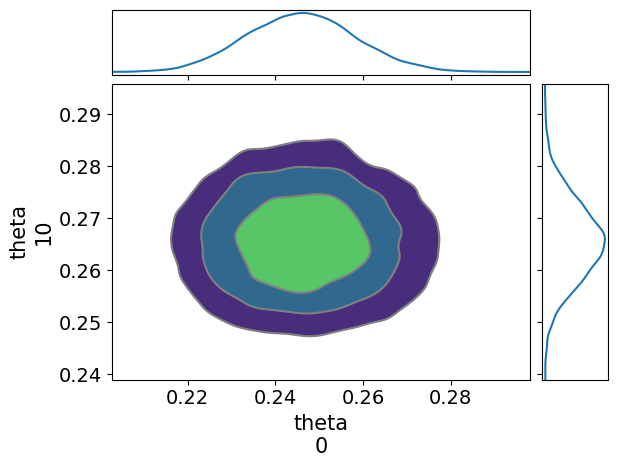

In [69]:
import arviz as az

# Asegúrate de haber creado idata con coords/dims nombrados (como te pasé antes):
# coords={"obs": df.index.to_numpy(), "distrito": distrito_names}, dims={"theta":["obs"], ...}

# Densidad 2D de thetas (no traza/path):
az.plot_pair(
    idata,
    var_names=["theta"],
    coords={"obs": [df.index[i], df.index[j]]},
    kind="kde", marginals=True
)
plt.show()


## STAN

In [72]:
import pandas as pd
import numpy as np

data = pd.read_csv("../data/clean/datos_limpios.csv")

# Limpia subtotal/total a numérico
for col in ["subtotal", "total"]:
    s = (data[col].astype(str).str.strip()
                   .str.replace(",", "", regex=False))
    data[col] = pd.to_numeric(s, errors="coerce")

# Conteos enteros
data["y"] = data["subtotal"].round().astype("Int64")
data["n"] = data["total"].round().astype("Int64")

covars = [
    "desempleo","poblacion_urbana","privacion_critica",
    "poblacion_menor_14","hogares_monomarentales",
    "ocupantes_por_hogar","anos_escolaridad"
]
cols_needed = ["distrito","y","n"] + covars

df = (data[cols_needed]
      .dropna(subset=["distrito","y","n"])
      .query("n >= 1 and y >= 0 and y <= n")
      .copy())

# Estandariza covariables
for c in covars:
    m, s = df[c].mean(), df[c].std(ddof=0)
    df[c] = (df[c] - m) / (s if s > 0 else 1.0)

# IDs de distrito (1..J)
df["distrito_id"], distrito_levels = pd.factorize(df["distrito"], sort=True)
df["distrito_id"] += 1

# Matrices/arrays para Stan
X = df[covars].to_numpy(float)  # N x K
y = df["y"].to_numpy(int)
n = df["n"].to_numpy(int)
dist_id = df["distrito_id"].to_numpy(int)
N, K = X.shape
J = int(df["distrito_id"].max())


In [73]:
from cmdstanpy import CmdStanModel
import tempfile, os

stan_code = r"""
data {
  int<lower=1> N;
  int<lower=1> K;
  int<lower=1> J;
  array[N] int<lower=0> y;
  array[N] int<lower=1> n;
  matrix[N, K] X;
  array[N] int<lower=1, upper=J> dist_id;
}
parameters {
  real alpha0;
  vector[K] beta;
  real<lower=0> sigma_alpha;
  vector[J] z_alpha;
}
transformed parameters {
  vector[J] alpha = sigma_alpha * z_alpha;
}
model {
  alpha0 ~ normal(0, 2);
  beta   ~ normal(0, 1);
  sigma_alpha ~ normal(0, 1);
  z_alpha ~ normal(0, 1);

  for (i in 1:N) {
    real eta = alpha0 + alpha[dist_id[i]] + X[i] * beta;
    y[i] ~ binomial_logit(n[i], eta);
  }
}
generated quantities {
  vector[N] theta;
  array[N] int y_rep;
  for (i in 1:N) {
    real eta = alpha0 + alpha[dist_id[i]] + X[i] * beta;
    theta[i] = inv_logit(eta);
    y_rep[i] = binomial_rng(n[i], theta[i]);
  }
}
"""

tmpdir = tempfile.mkdtemp(prefix="stan_prevlogit_")
stan_file = os.path.join(tmpdir, "binomial_logit_hier.stan")
with open(stan_file, "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file=stan_file)

fit = model.sample(
    data={"N": N, "K": K, "J": J, "y": y, "n": n, "X": X, "dist_id": dist_id},
    chains=4, parallel_chains=4, seed=123,
    iter_warmup=1000, iter_sampling=2000,
    adapt_delta=0.9, max_treedepth=12
)
print(fit.summary())


13:39:44 - cmdstanpy - INFO - compiling stan file C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5o61s8v_\binomial_logit_hier.stan to exe file C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5o61s8v_\binomial_logit_hier.exe
13:42:59 - cmdstanpy - INFO - compiled model executable: C:\Users\DELL\AppData\Local\Temp\stan_prevlogit_5o61s8v_\binomial_logit_hier.exe
13:42:59 - cmdstanpy - INFO - CmdStan start processing
chain 1 |                                                                                                | 00:00 Status
chain 2 |                                                                                                | 00:00 Status

chain 3 |                                                                                                | 00:00 Status


chain 1 |███▉                                                           | 01:55 Iteration:    1 / 3000 [  0%]  (Warmup)


chain 1 |█████▉                                                         | 02:01 Iteration:  100 /

KeyboardInterrupt: 


chain 1 |█████████████████████████████████████████████████▌           | 03:31 Iteration: 2300 / 3000 [ 76%]  (Sampling)


chain 4 |█████████████████████████████████████████████████▌           | 03:32 Iteration: 2300 / 3000 [ 76%]  (Sampling)
chain 1 |███████████████████████████████████████████████████▍         | 03:35 Iteration: 2400 / 3000 [ 80%]  (Sampling)


chain 4 |███████████████████████████████████████████████████▍         | 03:36 Iteration: 2400 / 3000 [ 80%]  (Sampling)
chain 1 |█████████████████████████████████████████████████████▍       | 03:39 Iteration: 2500 / 3000 [ 83%]  (Sampling)


chain 4 |█████████████████████████████████████████████████████▍       | 03:40 Iteration: 2500 / 3000 [ 83%]  (Sampling)
chain 1 |███████████████████████████████████████████████████████▎     | 03:43 Iteration: 2600 / 3000 [ 86%]  (Sampling)


chain 4 |███████████████████████████████████████████████████████▎     | 03:43 Iteration: 2600 / 3000 [ 86%]  (Sampling)
chain 1 |██████████████████████

In [ ]:
import numpy as np
import pandas as pd
import pyjags
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.stats import gaussian_kde

# -----------------------------
# CARGA Y PREPROCESO DE TUS DATOS
# -----------------------------
data = pd.read_csv("../data/clean/datos_limpios.csv")

# Limpia subtotal/total a numérico
for col in ["subtotal", "total"]:
    s = (data[col].astype(str).str.strip()
                  .str.replace(",", "", regex=False))
    data[col] = pd.to_numeric(s, errors="coerce")

# Define conteos (enteros)
data["y"] = data["subtotal"].round().astype("Int64")
data["n"] = data["total"].round().astype("Int64")

covars = [
    "desempleo","poblacion_urbana","privacion_critica",
    "poblacion_menor_14","hogares_monomarentales",
    "ocupantes_por_hogar","anos_escolaridad"
]
cols_needed = ["distrito","y","n"] + covars

df = (data[cols_needed]
      .dropna(subset=["distrito","y","n"])
      .query("n >= 1 and y >= 0 and y <= n")
      .copy())

# Estandariza X
for c in covars:
    m, s = df[c].mean(), df[c].std(ddof=0)
    df[c] = (df[c] - m) / (s if s > 0 else 1.0)

# IDs de distrito 1..J (JAGS indexa desde 1)
df["distrito_id"], distrito_levels = pd.factorize(df["distrito"], sort=True)
df["distrito_id"] += 1

# Matrices/arrays para JAGS
X = df[covars].to_numpy(dtype=float)  # N x K
y = df["y"].to_numpy(dtype=int)
n = df["n"].to_numpy(dtype=int)
dist_id = df["distrito_id"].to_numpy(dtype=int)

N, K = X.shape
J = int(df["distrito_id"].max())

# JAGS quiere listas nativas (no np arrays) para matrices/arrays
data_jags = {
    "N": int(N),
    "K": int(K),
    "J": int(J),
    "y": y.astype(int).tolist(),
    "n": n.astype(int).tolist(),
    "dist_id": dist_id.astype(int).tolist(),
    "X": X.tolist(),
}

# -----------------------------
# MODELO JAGS (NO CONJUGADO; LOGIT-NORMAL)
# -----------------------------
model_code = r"""
model {
  for (i in 1:N) {
    y[i] ~ dbin(theta[i], n[i])
    logit(theta[i]) <- alpha0 + alpha[dist_id[i]] + inprod(X[i,], beta[])
  }

  # Priors débiles
  alpha0 ~ dnorm(0, 1 / (2^2))        # N(0,2)
  for (k in 1:K) {
    beta[k] ~ dnorm(0, 1)             # N(0,1)
  }

  # Interceptos por distrito (pooling parcial)
  for (j in 1:J) {
    alpha[j] ~ dnorm(0, tau_alpha)    # var = 1/tau_alpha = sigma_alpha^2
  }

  # sigma_alpha ~ half-Normal(0,1) aproximado con truncamiento
  sigma_alpha ~ dnorm(0, 1) T(0,)     # >0
  tau_alpha <- 1 / pow(sigma_alpha, 2)

  # Posterior predictive
  for (i in 1:N) {
    y_rep[i] ~ dbin(theta[i], n[i])
  }
}
"""

# -----------------------------
# CORRER GIBBS/MH EN JAGS
# -----------------------------
# Adaptación y muestreo
chains = 4
adapt  = 2000
iters  = 4000     # draws guardados por cadena
thin   = 1

model = pyjags.Model(
    code=model_code,
    data=data_jags,
    chains=chains,
    adapt=adapt,
)

samples = model.sample(
    iters,
    vars=["alpha0","beta","sigma_alpha","alpha","theta","y_rep"],
    thin=thin,
)

# 'samples' es un dict con arrays [iters, chains, ...]
# Unificamos cadenas e iteraciones para algunos resúmenes
def stack(name):
    arr = samples[name]  # shape: (iters, chains, ...)
    s = arr.shape
    return arr.reshape(s[0]*s[1], *s[2:])

theta_draws = stack("theta")        # (draws, N)
alpha0_draws = stack("alpha0")      # (draws,)
sigma_draws  = stack("sigma_alpha") # (draws,)
beta_draws   = stack("beta")        # (draws, K)

# Resumen por observación (prevalencia de cada fila)
theta_mean = theta_draws.mean(axis=0)
theta_ci   = np.quantile(theta_draws, [0.025, 0.975], axis=0).T

res = df[["distrito","y","n"]].copy()
res["prev_estimada"] = theta_mean
res["ci_low"] = theta_ci[:,0]
res["ci_high"] = theta_ci[:,1]
print(res.head())

# -----------------------------
# CONVERTIR A ARVIZ (para trazas cómodas)
# -----------------------------
# Creamos coords/dims con nombres legibles
coords = {
    "covar": covars,
    "distrito": list(distrito_levels),
    "obs": df.index.to_numpy(),
}
dims = {
    "beta": ["covar"],
    "alpha": ["distrito"],
    "theta": ["obs"],
    "y_rep": ["obs"],
}

# ArviZ espera dict por cadena; construimos a partir de 'samples'
# Reordenamos a (chains, draws, ...)
def to_chains(name):
    arr = samples[name]   # (iters, chains, ...)
    return np.transpose(arr, (1,0) + tuple(range(2, arr.ndim)))

posterior = {
    "alpha0": to_chains("alpha0"),
    "sigma_alpha": to_chains("sigma_alpha"),
    "beta": to_chains("beta"),
    "alpha": to_chains("alpha"),
    "theta": to_chains("theta"),
}
posterior_predictive = {"y_rep": to_chains("y_rep")}
observed_data = {"y": np.broadcast_to(y[None, :], (chains, len(y)))}

idata = az.from_dict(
    posterior=posterior,
    posterior_predictive=posterior_predictive,
    observed_data=observed_data,
    coords=coords,
    dims=dims,
)

# -----------------------------
# TRAZAS (líneas de cómo llega a la distribución)
# -----------------------------
az.plot_trace(idata, var_names=["alpha0","sigma_alpha"])
plt.tight_layout(); plt.show()

# Betas específicas por nombre
az.plot_trace(idata, var_names=["beta"], coords={"covar": ["desempleo","poblacion_urbana","privacion_critica"]})
plt.tight_layout(); plt.show()

# Trazas de theta para algunos distritos
sel_distritos = [distrito_levels[0], distrito_levels[10], distrito_levels[20]]
az.plot_trace(idata, var_names=["theta"], coords={"obs": df.index[df["distrito"].isin(sel_distritos)]})
plt.tight_layout(); plt.show()

# También un "camino 2D" de dos thetas (como en la captura)
names = list(distrito_levels)
i_name, j_name = names[0], names[10]
i = names.index(i_name); j = names.index(j_name)
a = theta_draws[:, i]
b = theta_draws[:, j]
step = np.arange(1, len(a)+1)

fig, ax = plt.subplots(figsize=(6,5))
pts = np.column_stack([a, b])
segments = np.stack([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segments, cmap="viridis", norm=plt.Normalize(step.min(), step.max()))
lc.set_array(step[1:])
lc.set_linewidth(0.8)
ax.add_collection(lc)
ax.set_xlim(a.min()-0.02, a.max()+0.02)
ax.set_ylim(b.min()-0.02, b.max()+0.02)
ax.set_xlabel(f"theta[{i_name}]")
ax.set_ylabel(f"theta[{j_name}]")
ax.set_title("Camino MCMC (JAGS) coloreado por iteración")
plt.colorbar(lc, ax=ax, label="step")
plt.tight_layout(); plt.show()

# -----------------------------
# HEATMAP / DENSIDAD 2D DE LA POSTERIOR (dos distritos)
# -----------------------------
# Hexbin
plt.figure(figsize=(6,5))
hb = plt.hexbin(a, b, gridsize=40, cmap="viridis")
plt.colorbar(hb, label="conteo por celda")
plt.xlabel(f"theta[{i_name}]"); plt.ylabel(f"theta[{j_name}]")
plt.title("Hexbin posterior (JAGS)")
plt.tight_layout(); plt.show()

# KDE 2D
xy = np.vstack([a, b]); kde = gaussian_kde(xy)
xx, yy = np.meshgrid(np.linspace(a.min(), a.max(), 120),
                     np.linspace(b.min(), b.max(), 120))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, zz, levels=20, cmap="viridis")
plt.colorbar(label="densidad KDE")
plt.xlabel(f"theta[{i_name}]"); plt.ylabel(f"theta[{j_name}]")
plt.title("KDE 2D posterior (JAGS)")
plt.tight_layout(); plt.show()


In [74]:
!pip install pyjags arviz pandas numpy matplotlib scipy

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.4 MB 3.4 MB/s eta 0:00:02
   --------------------- ------------------ 3.4/6.4 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 14.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 42.6 MB/s  0:00:00
  Running setup.py clean for pyjags
Failed to build pyjags


  DEPRECATION: Building 'pyjags' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pyjags'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [35 lines of output]
  environment variable JAGS_HOME not defined, defaulting to C:\Program Files\JAGS\JAGS-4.3.0
  On 64 Bit Architecture
  C:\Users\DELL\.conda\envs\stan\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'test_suite'
    warnings.warn(msg)
  C:\Users\DELL\.conda\envs\stan\Lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers